**SEE ONENOTE FOR TODOS**

https://docs.mondaic.com/2024.1.3/examples/tutorials/sources_and_receivers/custom_stf/tutorial

In [ ]:
%matplotlib inline 

In [9]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_wavefield_custom_stf" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import salvus.flow.simple_config as sc
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

In [10]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

[2026-06-12 11:02:03,274] INFO: Loading project from simulation_wavefield_custom_stf.


Plotting source index 0 at x = 30.0 m (delay = 0.0000 s):


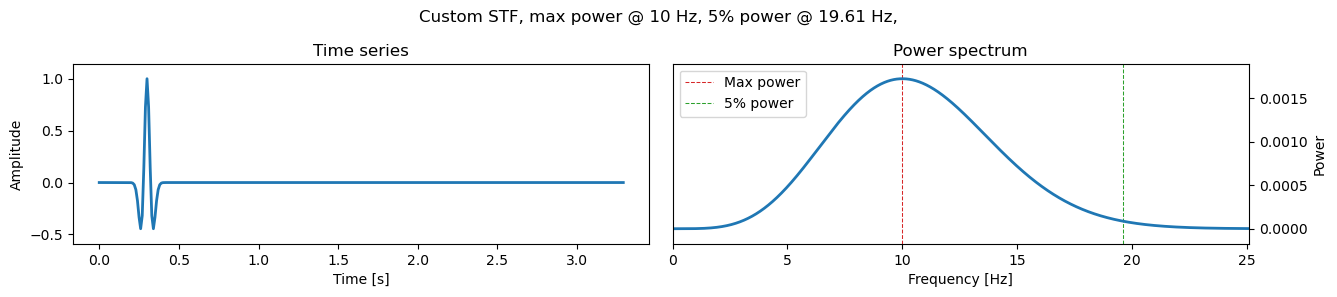

Plotting source index 1 at x = 30.5 m (delay = 0.0056 s):


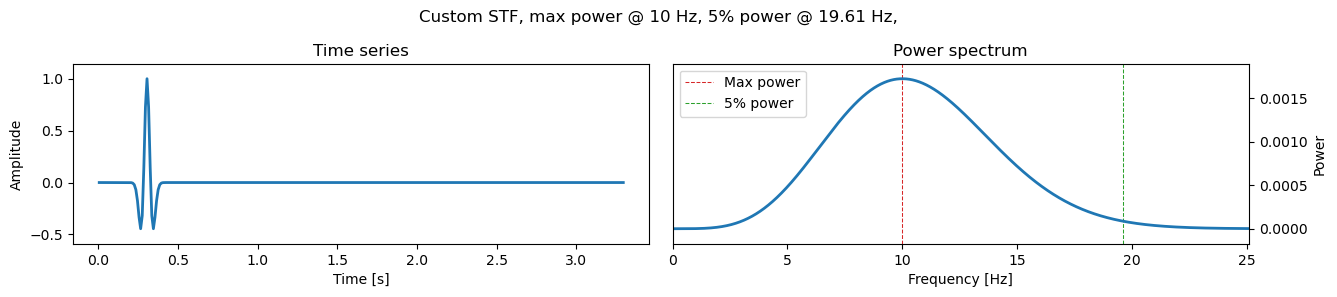

Plotting source index 2 at x = 31.0 m (delay = 0.0111 s):


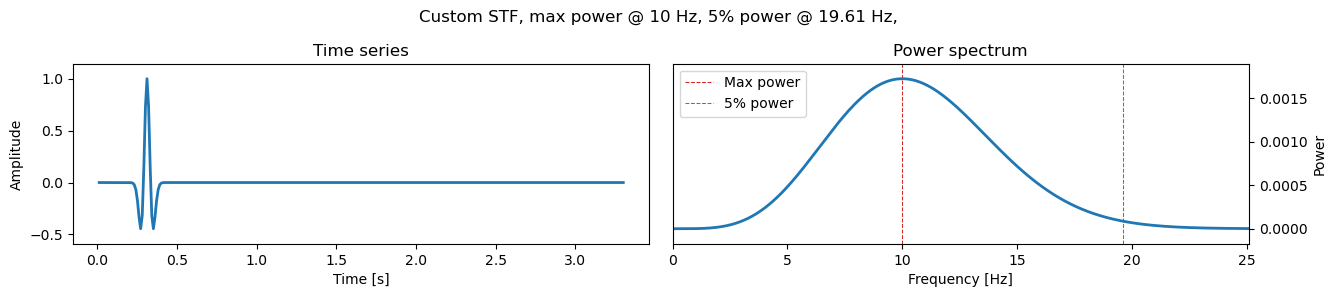

Plotting source index 3 at x = 31.5 m (delay = 0.0167 s):


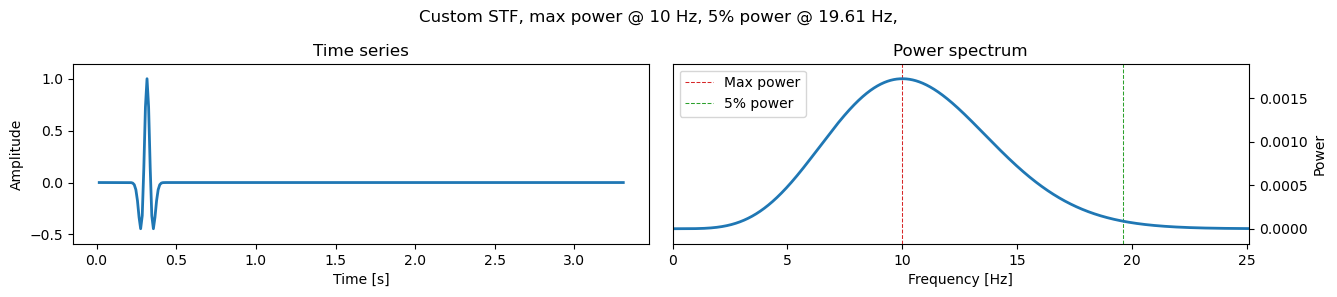

Plotting source index 4 at x = 32.0 m (delay = 0.0222 s):


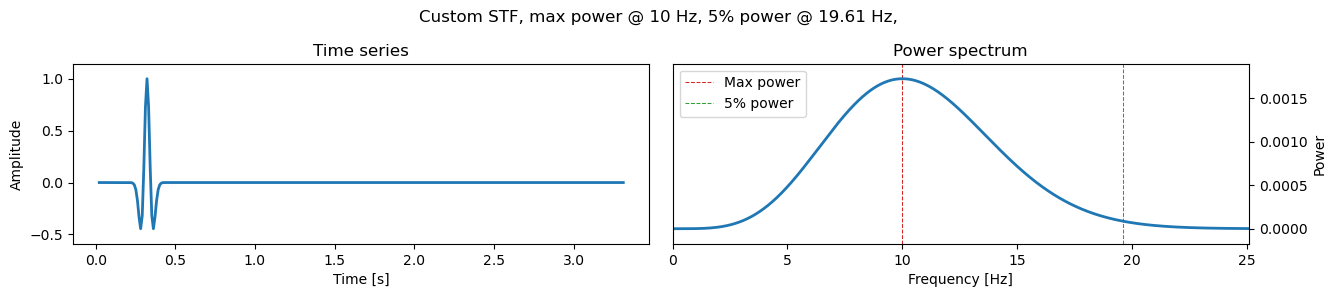

In [ ]:
# Defining custom ricker wavelet 
# formula for ricker from seg wiki: f(t)=(1-2\pi ^{2}f_{_{M}}^{2}t^{2})e^{-\pi ^{2}f_{_{M}}^{2}t^{2}}
f0 = 10 # central frequency in HZ
sampling_rate = 100 # in HZ
t = np.arange(-0.3, 3.0, 1/sampling_rate) # time vector from -0.3 to 3 seconds with step of 1/sampling_rate FOR THE ENTIRE SIMULATION

steps = 0.5 # distance between the sources in m
x_positions = np.arange(30.0, 270.0, steps) # source positions from 30 to 270 m with step 
target_vprop = 90 # target velocity, sub-rayleigh or supershear
dx = x_positions[1] - x_positions[0]
dt_src = dx / target_vprop
source_delays = np.arange(len(x_positions)) * dt_src

# create empthy source list to which the sources will be added 
srcs = []

# Looping over the source positions and time delays 
for i, x_src in enumerate(x_positions):
    delay = source_delays[i]
    
    stf = sc.stf.Custom.from_array(
        array=(1.0 - 2.0 * (np.pi * f0 * t) ** 2) * np.exp(-((np.pi * f0 * t) ** 2)),
        sampling_rate_in_hertz=sampling_rate,
        start_time_in_seconds=delay,
    )

    if i < 5:
        print(f"Plotting source index {i} at x = {x_src} m (delay = {delay:.4f} s):")
        stf.plot()
        fig = plt.gcf()
        from IPython.display import display
        display(fig)
        plt.close(fig)


    src = sc.source.cartesian.MomentTensorPoint2D(
        x=x_src,  
        y=2.625,
        mxx=0.0,
        myy=-1.54e+01,
        mxy=0.0,
        source_time_function=stf
    )

